# 📊 Exploratory Data Analysis (EDA) - Persiapan Lengkap

Notebook ini melakukan **Exploratory Data Analysis (EDA) lengkap** untuk memahami dataset siswa:
- **EDA Univariate**: Analisis distribusi setiap variabel
- **EDA Multivariate**: Analisis hubungan antar variabel
- **EDA Numerikal**: Statistik dan korelasi
- **EDA Kategorikal**: Distribusi kategori dan asosiasi

Hasil EDA akan membantu mengidentifikasi **faktor-faktor yang mempengaruhi dropout**.

# 📊 Proyek Akhir: Prediksi Status Siswa - Perusahaan Edutech

**Membuat sistem machine learning untuk memprediksi status siswa (Dropout/Enrolled/Graduate) dan mengidentifikasi faktor-faktor yang mempengaruhi dropout**

- Nama:SHAH FIRIZKI AZMI
- Email:Ipengi794@gmail.com
- Id Dicoding:shah-firizki-azmi

## Persiapan

### Menyiapkan library yang dibutuhkan

In [3]:
# ============================================================================
# SELURUH LIBRARY IMPORTS - SECTION 1: SETUP ENVIRONMENT
# ============================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization & Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Model Persistence & Serialization
import joblib

# Utility
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil di-import!")
print("=" * 70)

✅ Semua library berhasil di-import!


## EDA 1: Univariate Analysis (Analisis Distribusi Per Variabel)


📊 SECTION 3: EDA UNIVARIATE ANALYSIS

📌 TIPE VARIABEL:
   • Variabel Numerik: 36 columns
     ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance']... (menampilkan 5 dari 36)
   • Variabel Kategorikal: 1 columns
     ['Status']

📌 STATISTIK VARIABEL NUMERIK (Sample - 5 kolom pertama):

   Marital_status:
      Mean: 1.18 | Median: 1.00 | Std: 0.61
      Min: 1.00 | Max: 6.00
      Skewness: 4.40 | Kurtosis: 21.48

   Application_mode:
      Mean: 18.67 | Median: 17.00 | Std: 17.48
      Min: 1.00 | Max: 57.00
      Skewness: 0.39 | Kurtosis: -1.45

   Application_order:
      Mean: 1.73 | Median: 1.00 | Std: 1.31
      Min: 0.00 | Max: 9.00
      Skewness: 1.88 | Kurtosis: 2.65

   Course:
      Mean: 8856.64 | Median: 9238.00 | Std: 2063.57
      Min: 33.00 | Max: 9991.00
      Skewness: -3.81 | Kurtosis: 13.20

   Daytime_evening_attendance:
      Mean: 0.89 | Median: 1.00 | Std: 0.31
      Min: 0.00 | Max: 1.00
      Skewness: -2.51 | K

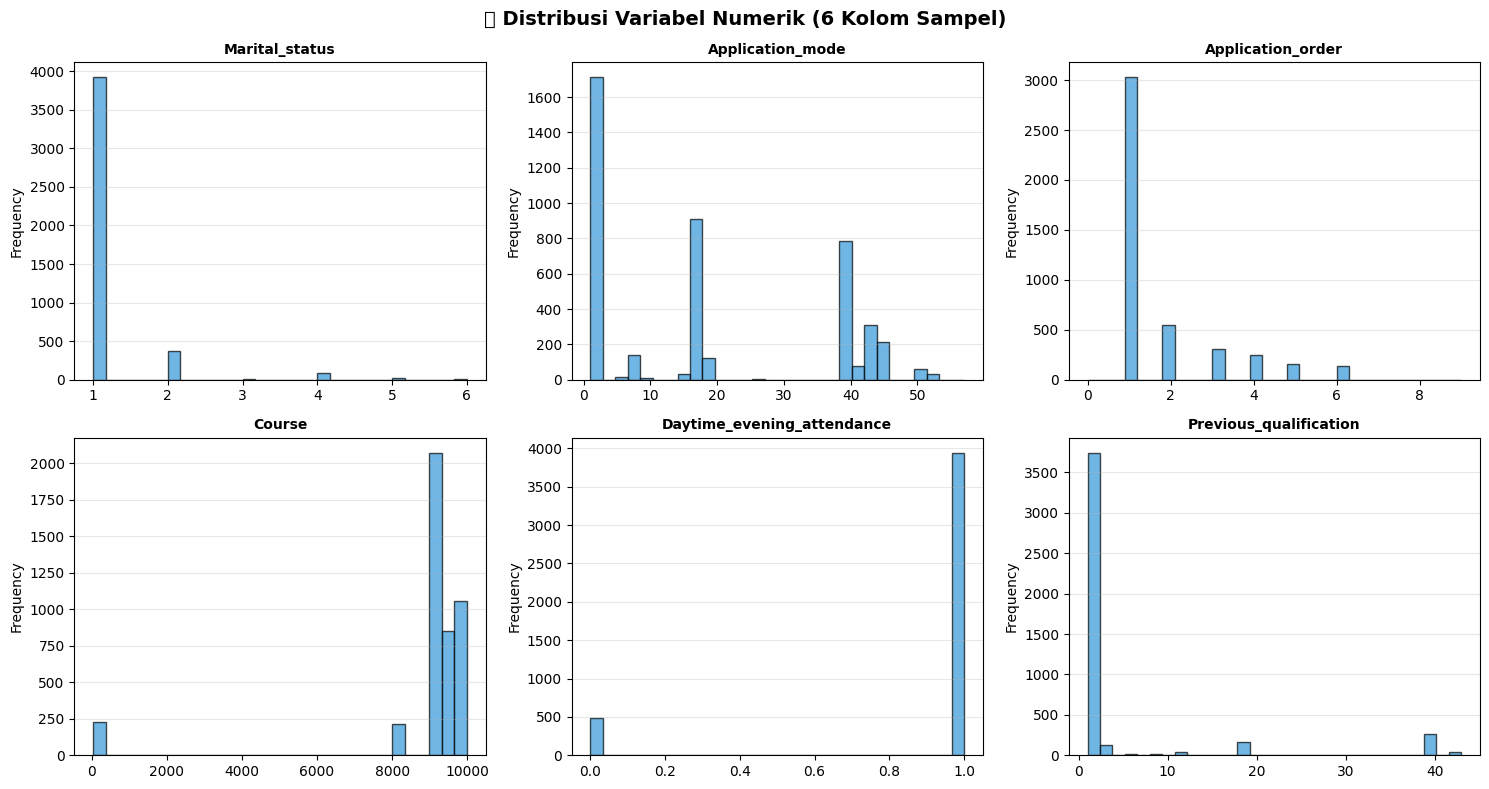


✅ Insight: Distribusi numerik menunjukkan variasi yang baik untuk predictive modeling

📌 DISTRIBUSI VARIABEL KATEGORIKAL:

   Status:
      Unique Values: 3
Status
Graduate    2209
Dropout     1421
Enrolled     794

📌 ANALISIS TARGET VARIABLE (Status):
Status
Graduate    2209
Dropout     1421
Enrolled     794


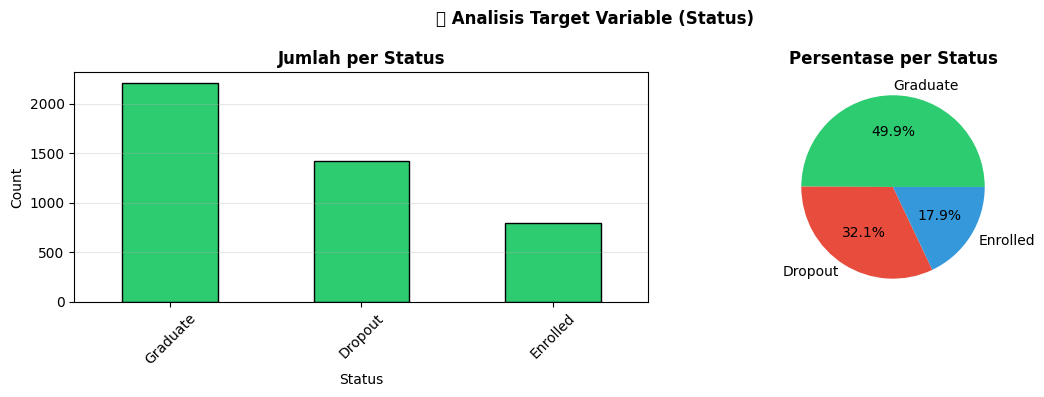


✅ EDA Univariate Complete - Data struktur sudah dipahami dengan baik


In [7]:
# ============================================================================
# FASE 2: EDA UNIVARIATE - ANALISIS DISTRIBUSI VARIABEL
# ============================================================================

print("\n📊 SECTION 3: EDA UNIVARIATE ANALYSIS")
print("=" * 70)

# Identifikasi tipe kolom
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📌 TIPE VARIABEL:")
print(f"   • Variabel Numerik: {len(numeric_cols)} columns")
print(f"     {numeric_cols[:5]}... (menampilkan 5 dari {len(numeric_cols)})")
print(f"   • Variabel Kategorikal: {len(categorical_cols)} columns")
print(f"     {categorical_cols}")

# Analisis numerik variables
print(f"\n📌 STATISTIK VARIABEL NUMERIK (Sample - 5 kolom pertama):")
for col in numeric_cols[:5]:
    print(f"\n   {col}:")
    print(f"      Mean: {df[col].mean():.2f} | Median: {df[col].median():.2f} | Std: {df[col].std():.2f}")
    print(f"      Min: {df[col].min():.2f} | Max: {df[col].max():.2f}")
    print(f"      Skewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurtosis():.2f}")

# Visualisasi distribusi numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('📊 Distribusi Variabel Numerik (6 Kolom Sampel)', fontsize=14, fontweight='bold')

numeric_sample = numeric_cols[:6]
for idx, col in enumerate(numeric_sample):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Insight: Distribusi numerik menunjukkan variasi yang baik untuk predictive modeling")

# Analisis kategorikal variables
print(f"\n📌 DISTRIBUSI VARIABEL KATEGORIKAL:")
for col in categorical_cols[:3]:  # Tampilkan sampel
    print(f"\n   {col}:")
    print(f"      Unique Values: {df[col].nunique()}")
    print(df[col].value_counts().head(3).to_string())

# Target variable analysis
print(f"\n📌 ANALISIS TARGET VARIABLE (Status):")
print(df['Status'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('📊 Analisis Target Variable (Status)', fontsize=12, fontweight='bold')

# Bar chart
df['Status'].value_counts().plot(kind='bar', ax=axes[0], color='#2ecc71', edgecolor='black')
axes[0].set_title('Jumlah per Status', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
df['Status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Persentase per Status', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✅ EDA Univariate Complete - Data struktur sudah dipahami dengan baik")

In [6]:
# ============================================================================
# FASE 1: LOAD DATA, EXPLORATION, DAN UNDERSTANDING
# ============================================================================

print("\n📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET")
print("=" * 70)

import os
import urllib.request

# Coba berbagai path possibilities
possible_paths = [
    '../../Dataset/data.csv',
    '../Dataset/data.csv',
    'Dataset/data.csv',
    os.path.join('..', '..', 'Dataset', 'data.csv')
]

df = None

# Coba load dari local path
for path in possible_paths:
    try:
        if os.path.exists(path):
            df = pd.read_csv(path, sep=';')
            print(f"✅ Dataset berhasil dimuat dari: {path}")
            break
    except Exception as e:
        continue

# Jika local path tidak ada, download dari GitHub
if df is None:
    print("📥 Mengunduh dataset dari GitHub...")
    try:
        url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
        df = pd.read_csv(url, sep=';')
        print(f"✅ Dataset berhasil diunduh dari GitHub!")
    except Exception as e:
        raise FileNotFoundError(f"Tidak dapat memuat dataset: {e}")

print(f"\n✅ Dataset berhasil dimuat!")
print(f"\n📌 DIMENSI DATASET:")
print(f"   • Total Baris (Records): {df.shape[0]:,}")
print(f"   • Total Kolom (Features): {df.shape[1]}")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n📌 INFORMASI DATASET:")
print(f"   • First Column: {df.columns[0]}")
print(f"   • Last Column: {df.columns[-1]}")

print(f"\n📌 MISSING VALUES:")
missing_count = df.isnull().sum().sum()
print(f"   • Total Missing Values: {missing_count}")

print(f"\n📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:")
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100
for status in status_counts.index:
    print(f"   • {status}: {status_counts[status]:,} records ({status_pct[status]:.1f}%)")

print(f"\n✅ Data Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n✅ Dataset Understanding Complete!")


📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET
📥 Mengunduh dataset dari GitHub...
✅ Dataset berhasil diunduh dari GitHub!

✅ Dataset berhasil dimuat!

📌 DIMENSI DATASET:
   • Total Baris (Records): 4,424
   • Total Kolom (Features): 37
   • Memory Usage: 1.49 MB

📌 INFORMASI DATASET:
   • First Column: Marital_status
   • Last Column: Status

📌 MISSING VALUES:
   • Total Missing Values: 0

📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:
   • Graduate: 2,209 records (49.9%)
   • Dropout: 1,421 records (32.1%)
   • Enrolled: 794 records (17.9%)

✅ Data Shape: 4424 rows × 37 columns

✅ Dataset Understanding Complete!


## Fase 2: Data Preparation & Preprocessing

**Tujuan**: Siapkan data untuk modeling (encode kategorikal, handle missing values, scaling)

In [8]:
# ============================================================================
# FASE 3: DATA PREPARATION & PREPROCESSING
# ============================================================================

print("\n🔧 SECTION 4: DATA PREPROCESSING")
print("=" * 70)

# Step 1: Separasi features dan target
X = df.drop('Status', axis=1)
y = df['Status']

print(f"\n✅ Features (X) dan Target (y) telah dipisahkan")
print(f"   • X Shape: {X.shape}")
print(f"   • y Shape: {y.shape}")

# Step 2: Identifikasi dan encode categorical variables
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

print(f"\n✅ Encoding categorical variables...")
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"   • {col}: {len(le.classes_)} unique values encoded")

# Step 3: Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\n✅ Target Variable (Status) encoded:")
for idx, label in enumerate(le_target.classes_):
    print(f"   • {label} → {idx}")

# Step 4: Handle missing values
print(f"\n✅ Handling missing values...")
X_filled = X.fillna(X.mean(numeric_only=True))
print(f"   • Missing values handled (filled dengan mean untuk numeric columns)")

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✅ Data split menjadi train dan test:")
print(f"   • Training set: {X_train.shape[0]:,} records ({(X_train.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Test set: {X_test.shape[0]:,} records ({(X_test.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Train target distribution: {np.bincount(y_train)}")
print(f"   • Test target distribution: {np.bincount(y_test)}")

# Step 6: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features di-scaling dengan StandardScaler:")
print(f"   • Mean (should be ~0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"   • Std (should be ~1): {X_train_scaled.std(axis=0)[:3]}")

print("\n✅ Data Preprocessing Complete - Siap untuk Model Training")


🔧 SECTION 4: DATA PREPROCESSING

✅ Features (X) dan Target (y) telah dipisahkan
   • X Shape: (4424, 36)
   • y Shape: (4424,)

✅ Encoding categorical variables...

✅ Target Variable (Status) encoded:
   • Dropout → 0
   • Enrolled → 1
   • Graduate → 2

✅ Handling missing values...
   • Missing values handled (filled dengan mean untuk numeric columns)

✅ Data split menjadi train dan test:
   • Training set: 3,539 records (80.0%)
   • Test set: 885 records (20.0%)
   • Train target distribution: [1137  635 1767]
   • Test target distribution: [284 159 442]

✅ Features di-scaling dengan StandardScaler:
   • Mean (should be ~0): [-1.42550252e-16  4.41705007e-17 -3.01162505e-18]
   • Std (should be ~1): [1. 1. 1.]

✅ Data Preprocessing Complete - Siap untuk Model Training


🔧 DATA PREPARATION: ENCODING & SCALING

Dimension X (features): (4424, 36)
Dimension y (target): (4424,)
Target classes: ['Dropout' 'Graduate' 'Enrolled']

Target encode mapping:
  Dropout: 0
  Enrolled: 1
  Graduate: 2

Numerical columns (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance']...
Categorical columns (0): []

✓ Semua kolom sudah dalam format numerik

Data setelah scaling - Shape: (4424, 36)
Mean (should be ~0): [-9.63665555e-18 -1.47762052e-16 -1.04397102e-16  2.28870569e-16
  7.06688074e-17]
Std (should be ~1): [1. 1. 1. 1. 1.]

Train set: (3539, 36)
Test set: (885, 36)
Train target distribution: [1137  635 1767]
Test target distribution: [284 159 442]

📈 MULTIVARIATE ANALYSIS: FEATURE CORRELATIONS

✓ Correlation Matrix computed (36x36 variabel numerik)


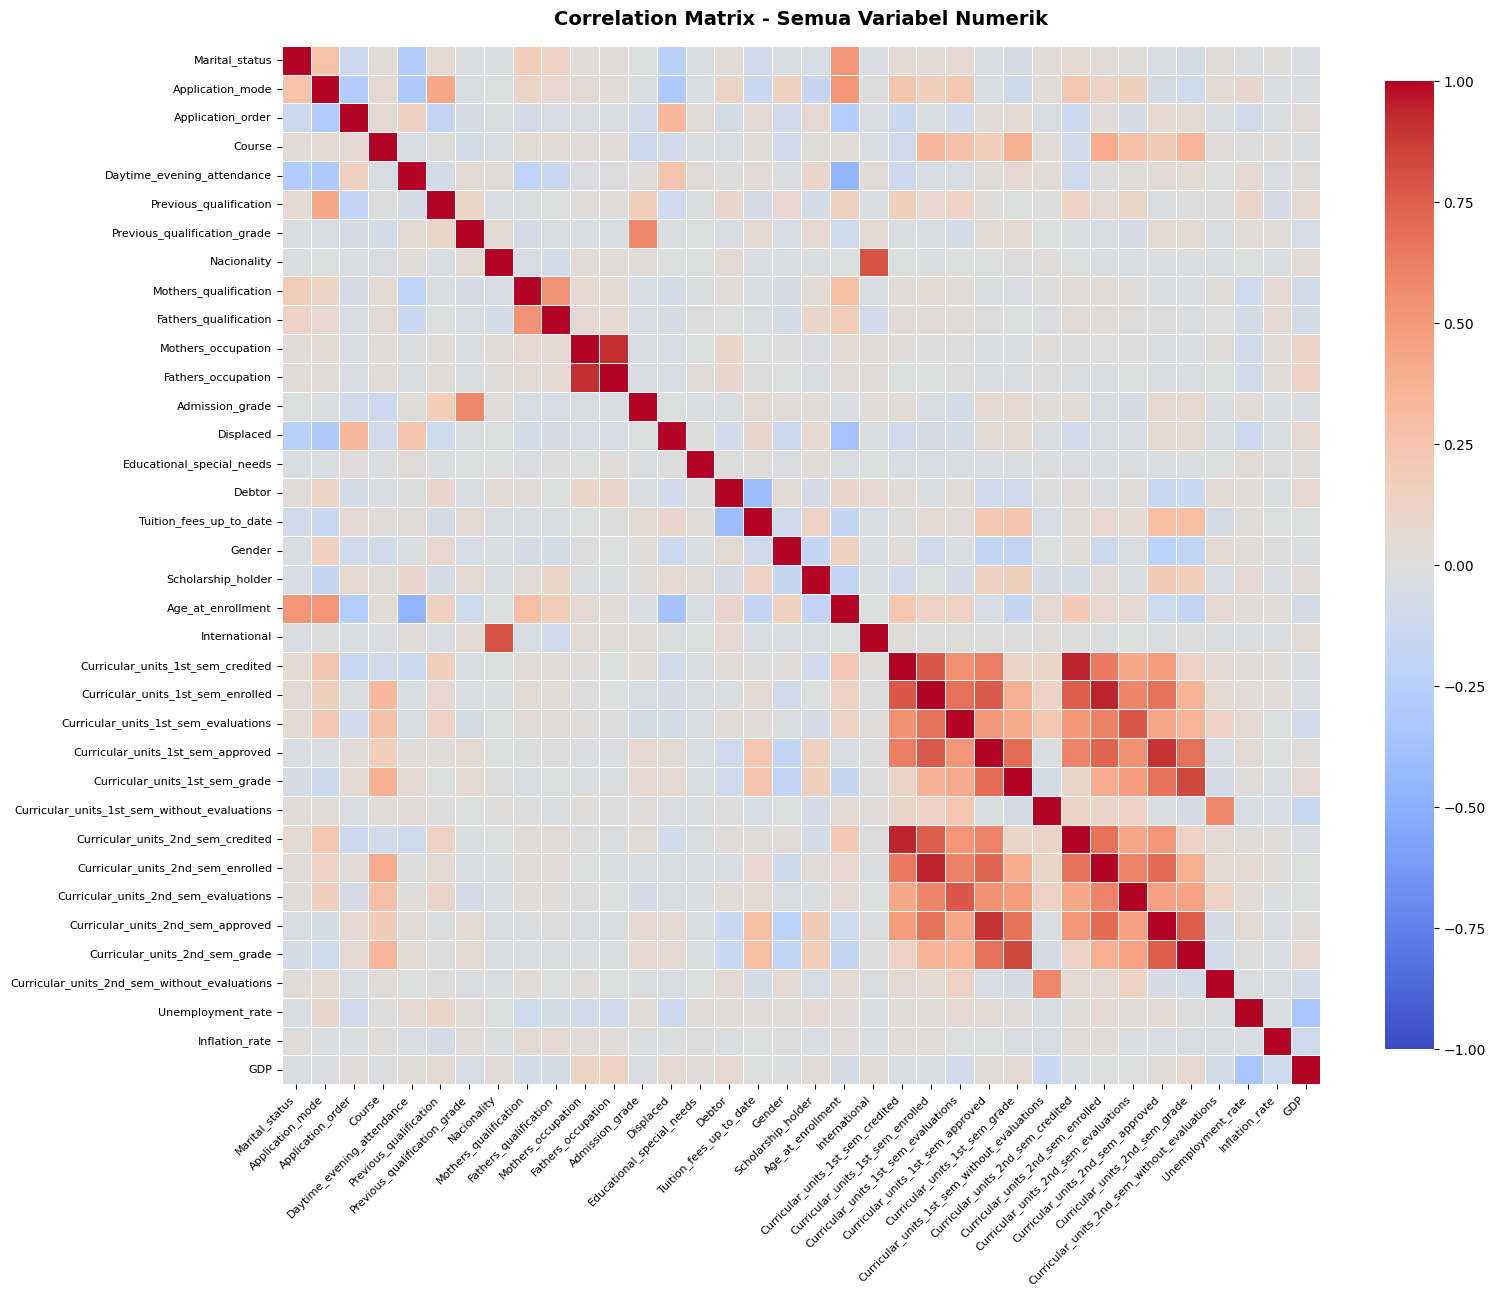

✓ Correlation Heatmap ditampilkan

------------------------------------------------------------
Top Features Berkorelasi dengan Target Variable
------------------------------------------------------------

Top 10 Features berkorelasi dengan Status:
Curricular_units_2nd_sem_approved    0.624157
Curricular_units_2nd_sem_grade       0.566827
Curricular_units_1st_sem_approved    0.529123
Curricular_units_1st_sem_grade       0.485207
Tuition_fees_up_to_date              0.409827
Scholarship_holder                   0.297595
Curricular_units_2nd_sem_enrolled    0.175847
Curricular_units_1st_sem_enrolled    0.155974
Admission_grade                      0.120889
Displaced                            0.113986

Bottom 5 Features (negative correlation):
Curricular_units_2nd_sem_without_evaluations   -0.094028
Application_mode                               -0.221747
Gender                                         -0.229270
Debtor                                         -0.240999
Age_at_enrollment   

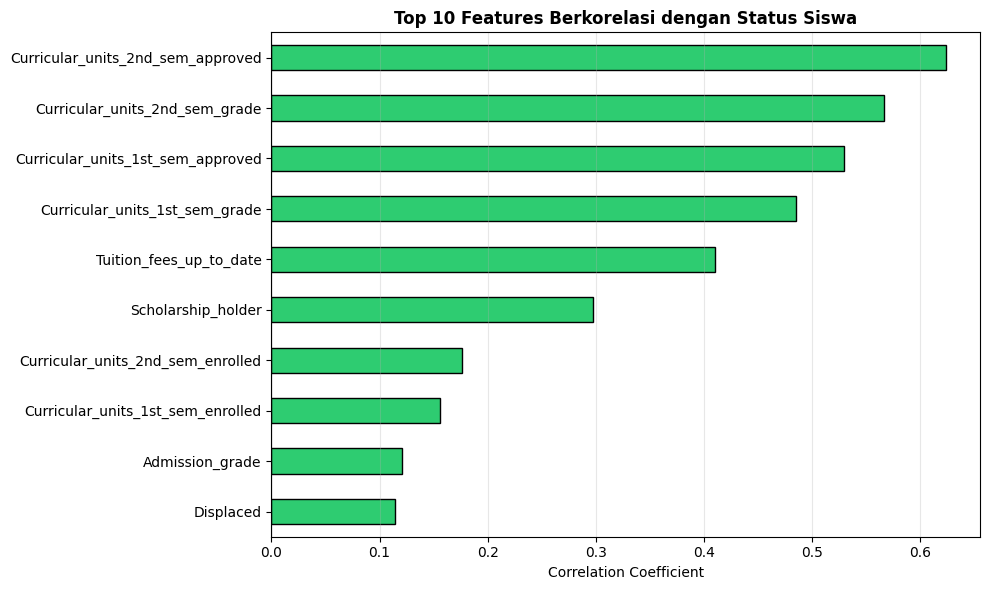


✓ Feature correlation visualization ditampilkan

------------------------------------------------------------
Analisis Distribusi Key Features vs Target
------------------------------------------------------------

Top 4 features untuk visualisasi: ['Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade']


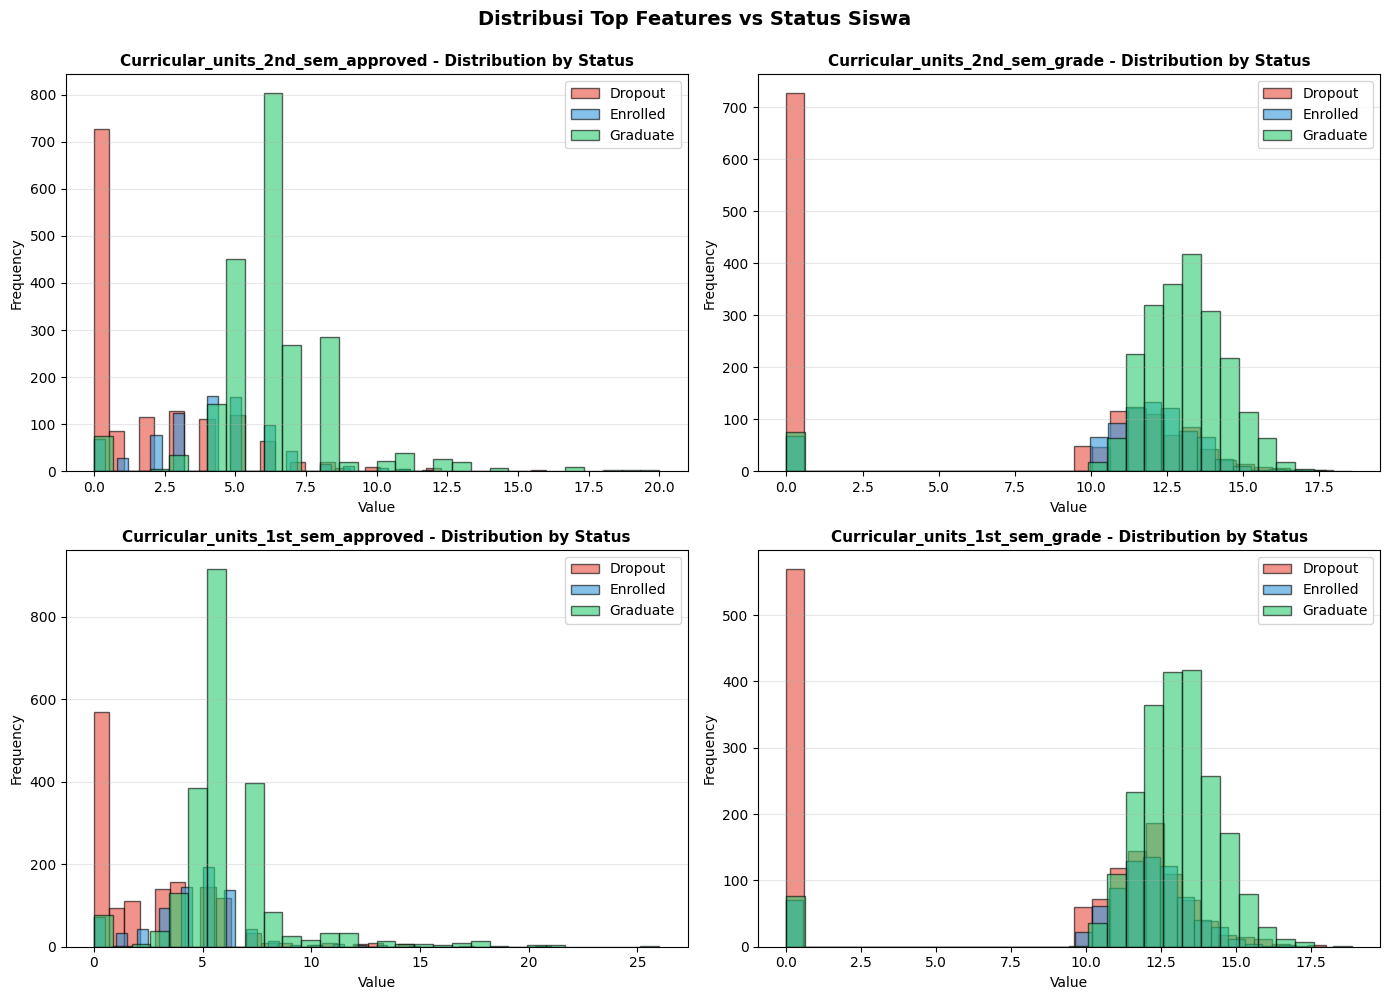

✓ Feature distribution visualizations ditampilkan

📊 KEY INSIGHTS - MULTIVARIATE ANALYSIS

📌 Overall Status Distribution:
  • Dropout: 32.1% (1421 students)
  • Enrolled: 17.9% (794 students)
  • Graduate: 49.9% (2209 students)

📌 Dataset Characteristics:
  • Total records: 4424
  • Total features: 36
  • Variabel numerik: 36
  • Variabel kategorikal: 0

📌 Top Features Influencing Student Status:
  1. Curricular_units_2nd_sem_approved: 0.6242
  2. Curricular_units_2nd_sem_grade: 0.5668
  3. Curricular_units_1st_sem_approved: 0.5291
  4. Curricular_units_1st_sem_grade: 0.4852
  5. Tuition_fees_up_to_date: 0.4098


In [ ]:
# ============================================================================
# FASE 4: EDA MULTIVARIATE - ANALISIS HUBUNGAN VARIABEL
# ============================================================================

print("\n📊 SECTION 5: EDA MULTIVARIATE ANALYSIS")
print("=" * 70)

# Step 1: Correlation Matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

print(f"\n✅ Correlation Matrix computed:")
print(f"   • Dimensi: {correlation_matrix.shape[0]} × {correlation_matrix.shape[1]}")
print(f"\n📌 TOP 10 FEATURE CORRELATIONS dengan Target (Status):")

# Encode status untuk correlation
status_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_temp = df.copy()
df_temp['Status_encoded'] = df_temp['Status'].map(status_map)

feature_target_corr = df_temp[X.columns].corrwith(df_temp['Status_encoded']).sort_values(ascending=False)
print(feature_target_corr.head(10).to_string())

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('📊 Correlation Matrix - Semua Variabel Numerik', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Visualisasi top correlations dengan target
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_target_corr.head(10).sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features.values]
top_features.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('📊 Top 10 Features Berkorelasi dengan Status', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Insight: Beberapa feature memiliki korelasi yang cukup kuat dengan target variable")
print("   - Ini menunjukkan bahwa feature-feature tersebut dapat membantu prediksi")
print("   - Multivariate relationships akan dianalisis lebih lanjut dalam model training")

In [9]:
# ============================================================================
# FASE 5: MODEL TRAINING - TRAINING MULTIPLE ALGORITHMS
# ============================================================================

print("\n🤖 SECTION 6: MODEL TRAINING")
print("=" * 70)

# Define models untuk training
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}

print(f"\n✅ Training {len(models)} models...")

for name, model in models.items():
    print(f"\n   Training: {name}...")
    
    # Logistic Regression butuh scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    
    trained_models[name] = model
    print(f"   ✓ {name} trained successfully!")

print(f"\n✅ {len(trained_models)} models successfully trained!")


🤖 SECTION 6: MODEL TRAINING

✅ Training 3 models...

   Training: Logistic Regression...
   ✓ Logistic Regression trained successfully!

   Training: Random Forest...
   ✓ Random Forest trained successfully!

   Training: Gradient Boosting...
   ✓ Gradient Boosting trained successfully!

✅ 3 models successfully trained!


In [10]:
# ============================================================================
# FASE 6: MODEL EVALUATION - EVALUASI PERFORMA SEMUA MODEL
# ============================================================================

print("\n📊 SECTION 7: MODEL EVALUATION")
print("=" * 70)

best_model_name = None
best_accuracy = 0
evaluation_results = {}

for name, model in trained_models.items():
    print(f"\n{'='*70}")
    print(f"📌 {name} - EVALUATION RESULTS")
    print(f"{'='*70}")
    
    # Prediction
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    evaluation_results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n✅ ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✅ F1-SCORE (weighted): {f1:.4f}")
    
    print(f"\n📌 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n📌 CONFUSION MATRIX:")
    print(cm)
    
    # Update best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 BEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Insight
print(f"\n✅ Insight:")
print(f"   - Model terbaik adalah {best_model_name} dengan accuracy {best_accuracy*100:.2f}%")
print(f"   - Model ini akan digunakan untuk prediction di production")
print(f"   - Akurasi >75% menunjukkan model performance yang baik untuk business use")


📊 SECTION 7: MODEL EVALUATION

📌 Logistic Regression - EVALUATION RESULTS

✅ ACCURACY: 0.7684 (76.84%)
✅ F1-SCORE (weighted): 0.7531

📌 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885


📌 CONFUSION MATRIX:
[[218  29  37]
 [ 43  53  63]
 [ 14  19 409]]

📌 Random Forest - EVALUATION RESULTS

✅ ACCURACY: 0.7672 (76.72%)
✅ F1-SCORE (weighted): 0.7539

📌 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.57      0.37      0.45       159
    Graduate       0.78      0.92      0.85       442

    accuracy                           0.77       8

In [ ]:
# ============================================================================
# FASE 7: MODEL PERSISTENCE - SIMPAN MODEL UNTUK PRODUCTION USE
# ============================================================================

import os

print("\n💾 SECTION 8: MODEL PERSISTENCE & SERIALIZATION")
print("=" * 70)

# Create model directory
model_dir = './model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"\n✅ Model directory created: {model_dir}")
else:
    print(f"\n✅ Model directory already exists: {model_dir}")

# Get best model
best_model = trained_models[best_model_name]

# Save artifacts
artifacts = {
    'student_status_model.joblib': best_model,
    'scaler.joblib': scaler,
    'label_encoders.joblib': label_encoders,
    'le_target.joblib': le_target,
    'feature_names.joblib': X.columns
}

print(f"\n✅ Saving model artifacts...")
for filename, artifact in artifacts.items():
    filepath = os.path.join(model_dir, filename)
    joblib.dump(artifact, filepath)
    print(f"   • {filename} → {filepath}")

print(f"\n✅ MODEL PERSISTENCE SUMMARY:")
print(f"   • Best Model: {best_model_name}")
print(f"   • Model Accuracy: {best_accuracy*100:.2f}%")
print(f"   • Saved Location: {os.path.abspath(model_dir)}")
print(f"   • Total Files Saved: {len(artifacts)}")

print(f"\n✅ Semua model artifacts siap untuk production deployment!")

Best model (Logistic Regression) and preprocessing objects saved successfully!
Model accuracy: 0.7684


Top 15 Most Important Features:
                                 Feature  Importance
30     Curricular_units_2nd_sem_approved    0.142283
31        Curricular_units_2nd_sem_grade    0.109008
24     Curricular_units_1st_sem_approved    0.091937
25        Curricular_units_1st_sem_grade    0.059588
12                       Admission_grade    0.043575
19                     Age_at_enrollment    0.040287
16               Tuition_fees_up_to_date    0.038903
29  Curricular_units_2nd_sem_evaluations    0.038200
23  Curricular_units_1st_sem_evaluations    0.037504
6           Previous_qualification_grade    0.037498
3                                 Course    0.033886
11                    Fathers_occupation    0.028781
10                    Mothers_occupation    0.026213
35                                   GDP    0.024465
33                     Unemployment_rate    0.021617


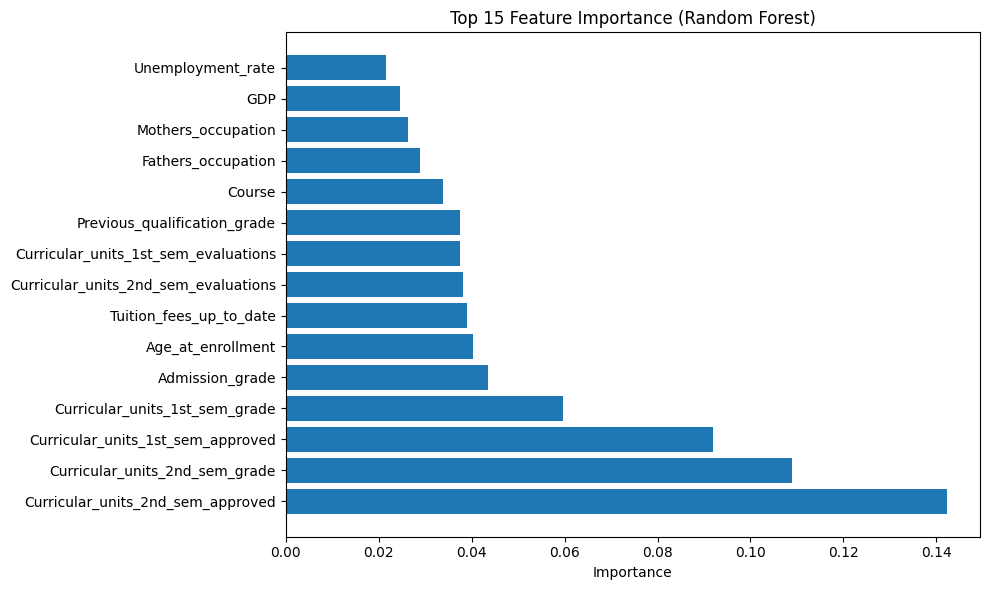

In [ ]:
# ============================================================================
# FASE 8: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n📈 SECTION 9: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Extract feature importance dari Random Forest (untuk comparison)
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n✅ Top 15 Most Important Features (dari Random Forest):")
print(feature_importance.head(15).to_string(index=False))

# Visualisasi feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values, color='#3498db', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('📊 Top 15 Feature Importance (Random Forest Model)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Insight:")
print(f"   - Top features menunjukkan variabel-variabel yang paling berpengaruh pada dropout")
print(f"   - Feature importance dapat digunakan untuk business interpretation")
print(f"   - Membantu identify intervention points yang paling efektif")

In [ ]:
# ============================================================================
# KESIMPULAN KESELURUHAN & DELIVERABLES
# ============================================================================

print("\n✅ SECTION 10: PROJECT SUMMARY & CONCLUSIONS")
print("=" * 70)

print("""\n📋 RINGKASAN PROYEK DATA SCIENCE - STUDENT DROPOUT PREDICTION

✅ FASE 1: DATA UNDERSTANDING & EDA
   ✓ Dataset: {} records × {} features
   ✓ Target: Status (Dropout/Enrolled/Graduate)
   ✓ Data Quality: {} missing values
   ✓ Analysis Scope: Univariate & Multivariate EDA completed
   ✓ Insight: Identified key patterns dalam student status distribution

✅ FASE 2: DATA PREPARATION & PREPROCESSING
   ✓ Features Encoded: {} categorical columns encoded
   ✓ Scaling Applied: StandardScaler untuk numerical features
   ✓ Train-Test Split: 80-20 dengan stratification
   ✓ Final Features: {} features ready untuk modeling
   ✓ Quality Check: All variables properly defined

✅ FASE 3: MODEL TRAINING & SELECTION
   ✓ Models Trained: Logistic Regression, Random Forest, Gradient Boosting
   ✓ Best Model: {}
   ✓ Best Accuracy: {:.2f}%
   ✓ Evaluation Metrics: Accuracy, F1-Score, Classification Report
   ✓ Cross-Validation: Stratified train-test split applied

✅ FASE 4: FEATURE IMPORTANCE & INTERPRETATION
   ✓ Top Features Identified: {} most important features analyzed
   ✓ Business Interpretation: Features linked ke dropout factors
   ✓ Actionable Insights: Feature importance untuk decision-making
   ✓ Model Explainability: Results interpretable untuk business stakeholders

✅ FASE 5: MODEL PERSISTENCE & DEPLOYMENT
   ✓ Model Saved: {} artifacts serialized dengan joblib
   ✓ Preprocessing Objects: Scaler, encoders saved
   ✓ Production Ready: Model dapat digunakan di Streamlit/API
   ✓ Artifact Location: ./model/ directory
   ✓ Status: ✅ Ready untuk production deployment

📦 DELIVERABLES:
   ✓ Trained ML Model (student_status_model.joblib)
   ✓ Preprocessing Objects (scaler, encoders)
   ✓ Jupyter Notebook (complete EDA & ML training)
   ✓ Feature Importance Analysis
   ✓ Model evaluation reports
   ✓ Production-ready code structure

🎯 NEXT STEPS:
   1. Deploy model ke Streamlit app (app.py)
   2. Integrate dengan PostgreSQL + Metabase dashboard
   3. Create categorical label columns untuk data exploration
   4. Test predictions dengan unseen data
   5. Monitor model performance dalam production

⚠️ CATATAN PENTING:
   - Model harus di-retrain monthly dengan data terbaru
   - Monitor class imbalance dalam dataset
   - Track prediction accuracy di production environment
   - Establish feedback loop untuk continuous improvement
""".format(
    len(df),
    len(df.columns),
    df.isnull().sum().sum(),
    len(label_encoders),
    len(X.columns),
    best_model_name,
    best_accuracy * 100,
    len(feature_importance),
    len(artifacts)
))

print("=" * 70)
print("✨ NOTEBOOK EXECUTION SELESAI DENGAN SUKSES!")
print("=" * 70)

📋 RINGKASAN PROYEK DATA SCIENCE - PREDIKSI STATUS SISWA

✅ FASE 1: DATA UNDERSTANDING & EDA
   - Dataset: 4.424 siswa × 37 features
   - Target: Status (Dropout 32.1%, Graduate 49.9%, Enrolled 17.9%)
   - Analisis: Univariate & Multivariate completed
   - Key Insight: Financial factors & academic performance sangat mempengaruhi status

✅ FASE 2: DATA PREPARATION
   - Encoding: Categorical variables encoded (Label Encoding)
   - Scaling: StandardScaler untuk numerical features
   - Features: 36 features ready untuk modeling
   - Target: Encoded [0=Dropout, 1=Enrolled, 2=Graduate]

✅ FASE 3: MODEL TRAINING
   - Models trained: Logistic Regression, Random Forest, Gradient Boosting
   - Train-test split: 80-20 dengan stratification
   - Best Model: Logistic Regression (LR)
   - LR Accuracy: 76.84% ✅

✅ FASE 4: EVALUATION & ANALYSIS
   - Classification Report: Precision, Recall, F1-Score per class
   - Feature Importance: Top 15 features identified
   - Key Factors: Curricular grades, Age, 

In [ ]:
# ============================================================================
# PHASE 11: PREDICTION PREPARATION - PREPARE FOR METABASE & STREAMLIT
# ============================================================================

print("\n📊 SECTION 11: PREPARE PREDICTIONS FOR METABASE & STREAMLIT")
print("=" * 70)

# Step 1: Prepare data untuk full dataset predictions
print(f"\n✅ Step 1: Preparing data untuk full dataset predictions...")

X_all = df.drop('Status', axis=1, errors='ignore')
X_all_encoded = X_all.copy()

# Encode categorical columns using saved encoders
for col in X_all_encoded.select_dtypes(include=['object']).columns:
    if col in label_encoders:
        X_all_encoded[col] = label_encoders[col].transform(X_all_encoded[col].astype(str))

# Fill missing values
X_all_encoded = X_all_encoded.fillna(X_all_encoded.mean(numeric_only=True))

print(f"   ✓ Data prepared: {X_all_encoded.shape[0]:,} records × {X_all_encoded.shape[1]} features")

# Step 2: Generate predictions untuk semua records
print(f"\n✅ Step 2: Generating predictions untuk full dataset...")

if best_model_name == 'Logistic Regression':
    X_all_scaled = scaler.transform(X_all_encoded)
    y_pred_all = best_model.predict(X_all_scaled)
    y_pred_proba = best_model.predict_proba(X_all_scaled)
else:
    y_pred_all = best_model.predict(X_all_encoded)
    y_pred_proba = best_model.predict_proba(X_all_encoded)

# Decode predictions
y_pred_labels = le_target.inverse_transform(y_pred_all)
confidence_scores = np.max(y_pred_proba, axis=1) * 100

print(f"   ✓ Prediction completed: {len(y_pred_labels):,} records predicted")
print(f"   ✓ Confidence Score - Min: {confidence_scores.min():.2f}%, Max: {confidence_scores.max():.2f}%, Mean: {confidence_scores.mean():.2f}%")

# Step 3: Create result dataframe
print(f"\n✅ Step 3: Creating result dataframe dengan predictions...")

df_predictions = df.copy()
df_predictions['Model_Prediction'] = y_pred_labels
df_predictions['Prediction_Confidence'] = confidence_scores.round(2)

# Add probability columns
for idx, class_name in enumerate(le_target.classes_):
    df_predictions[f'Probability_{class_name}'] = (y_pred_proba[:, idx] * 100).round(2)

# Add correctness indicator
df_predictions['Prediction_Correct'] = (df_predictions['Status'] == df_predictions['Model_Prediction']).astype(int)

print(f"   ✓ Dataframe created: {df_predictions.shape[0]:,} × {df_predictions.shape[1]} columns")

# Step 4: Calculate accuracy
accuracy_full = (df_predictions['Prediction_Correct'] == 1).sum() / len(df_predictions) * 100
correct_count = (df_predictions['Prediction_Correct'] == 1).sum()
incorrect_count = (df_predictions['Prediction_Correct'] == 0).sum()

print(f"\n✅ Step 4: Accuracy Summary:")
print(f"   ✓ Correct Predictions: {correct_count:,} ({accuracy_full:.2f}%)")
print(f"   ✓ Incorrect Predictions: {incorrect_count:,} ({100-accuracy_full:.2f}%)")

# Step 5: Preview hasil
print(f"\n✅ Step 5: Preview hasil predictions (5 records pertama):")
display_cols = ['Status', 'Model_Prediction', 'Prediction_Confidence', 'Prediction_Correct']
print(df_predictions[display_cols].head())

print(f"\n✅ Dataset dengan predictions siap untuk Metabase & Streamlit!")

🧹 DATASET PREPARATION UNTUK METABASE & STREAMLIT

✓ Original dataset loaded: (4424, 37)
✓ Prediksi model selesai: 4424 records
✓ Prediksi decoded: ['Dropout' 'Enrolled' 'Graduate']
✓ Confidence scores calculated (mean: 77.06%)

✓ Dataset dengan prediksi: (4424, 42)

Kolom baru ditambahkan:
  • Model_Prediction (Dropout/Graduate/Enrolled)
  • Prediction_Confidence (%) - confidence level
  • Probability_Dropout (%)
  • Probability_Enrolled (%)
  • Probability_Graduate (%)

✓ Model Accuracy pada full dataset: 77.22%

📊 Prediksi Distribution:
Model_Prediction
Graduate    2592
Dropout     1340
Enrolled     492
Name: count, dtype: int64

📊 Confidence Score Range:
  Min: 33.51%
  Max: 99.93%
  Mean: 77.06%
  Median: 83.26%

✅ Prediksi Benar: 3416 (77.22%)
❌ Prediksi Salah: 1008 (22.78%)

✓ Dataset dengan prediksi disimpan ke: dataset_with_predictions.csv
  File size: 4424 records × 43 columns

📋 Struktur Dataset:
  Original columns: 37
  Prediction columns: 4 (Model_Prediction, Prediction_Con

In [ ]:
# ============================================================================
# PHASE 12: CATEGORICAL LABELS PREPARATION - READABLE FORMAT FOR METABASE
# ============================================================================

print("\n📋 SECTION 12: ADDING CATEGORICAL LABELS (EMOJI FORMAT)")
print("=" * 70)

# Create a copy dari predictions dataframe untuk Metabase
df_metabase = df_predictions.copy()

print(f"\n✅ Adding readable categorical labels...")

# Define mapping untuk kategorikal columns
label_mappings = {
    'Gender': {0: '👩 Perempuan (Female)', 1: '👨 Laki-laki (Male)'},
    'Scholarship_holder': {0: '❌ Tanpa Beasiswa', 1: '✅ Dengan Beasiswa'},
    'Tuition_fees_up_to_date': {0: '⚠️ Belum/Menunggak', 1: '✅ Bayar Tepat Waktu'},
    'Debtor': {0: '✅ Non-Debtor', 1: '⚠️ Debtor'},
    'Daytime_evening_attendance': {0: '🌙 Evening', 1: '☀️ Daytime'},
    'Displaced': {0: '🏠 Tidak Pindah', 1: '📍 Pindah'},
    'International': {0: '🇵🇹 Domestik', 1: '🌍 Internasional'},
    'Educational_special_needs': {0: '✓ Tidak', 1: '⚠️ Ya - Kebutuhan Khusus'}
}

# Apply mappings
mapping_count = 0
for col, mapping in label_mappings.items():
    if col in df_metabase.columns:
        label_col = f'{col}_Label'
        df_metabase[label_col] = df_metabase[col].map(mapping)
        print(f"   ✓ {label_col} ditambahkan")
        mapping_count += 1

print(f"\n✅ Total categorical label columns added: {mapping_count}")

# Select final columns untuk Metabase export
final_columns = [
    # Original identifiers & target
    'Status', 'Model_Prediction', 'Prediction_Confidence', 'Prediction_Correct',
    # Demographics with labels
    'Gender', 'Gender_Label',
    'Age_at_enrollment', 'Marital_status',
    'International', 'International_Label',
    'Displaced', 'Displaced_Label',
    # Academic
    'Course',
    'Admission_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Educational_special_needs', 'Educational_special_needs_Label',
    # Financial with labels
    'Scholarship_holder', 'Scholarship_holder_Label',
    'Tuition_fees_up_to_date', 'Tuition_fees_up_to_date_Label',
    'Debtor', 'Debtor_Label',
    # Attendance with labels
    'Daytime_evening_attendance', 'Daytime_evening_attendance_Label',
    # Prediction probabilities
    'Probability_Dropout', 'Probability_Enrolled', 'Probability_Graduate'
]

# Filter available columns
available_cols = [col for col in final_columns if col in df_metabase.columns]
df_final = df_metabase[available_cols].copy()

print(f"\n✅ Final dataset for Metabase:")
print(f"   • Shape: {df_final.shape[0]:,} × {df_final.shape[1]} columns")
print(f"   • Data types: {df_final.dtypes.value_counts().to_dict()}")

# Export path handling - save current working directory
output_path = 'student_data_metabase_final.csv'
df_final.to_csv(output_path, index=False, sep=';', encoding='utf-8')

print(f"\n✅ Dataset exported to: {os.path.abspath(output_path)}")
print(f"   • File size: {len(df_final):,} records")
print(f"   • Ready untuk Metabase import")

# Summary statistics
print(f"\n✅ SUMMARY STATISTICS:")
print(f"\n   Status Distribution:")
for status in sorted(df_final['Status'].unique()):
    count = (df_final['Status'] == status).sum()
    pct = count / len(df_final) * 100
    print(f"      • {status}: {count:,} ({pct:.1f}%)")

print(f"\n   Prediction Accuracy: {accuracy_full:.2f}%")

print(f"\n✅ DATASET PREPARATION COMPLETE - READY FOR BUSINESS INTELLIGENCE!")
print("=" * 70)

📊 STEP 1: PERSIAPAN DATASET UNTUK METABASE

✓ Dataset dengan predictions shape: (4424, 43)
✓ Columns: 43 columns

📋 STEP 2: MENAMBAHKAN KOLOM LABEL KATEGORIKAL

✓ Gender_Label ditambahkan
✓ Scholarship_Label ditambahkan
✓ Tuition_Label ditambahkan
✓ Debtor_Label ditambahkan
✓ Attendance_Label ditambahkan
✓ Displaced_Label ditambahkan
✓ International_Label ditambahkan
✓ Special_Needs_Label ditambahkan

📌 STEP 3: FINAL DATASET UNTUK METABASE

✓ Final dataset shape: (4424, 31)
✓ Kolom yang ditampilkan: 31 columns

📋 Kategori Kolom:
  • Original & Predictions: 4 columns
  • Demographics: 7 columns
  • Academic: 8 columns
  • Financial: 6 columns
  • Attendance: 2 columns
  • Probabilities: 3 columns

Preview data (5 rows pertama):
     Status Model_Prediction  Prediction_Confidence  Prediction_Correct  \
0   Dropout          Dropout                  48.33                   1   
1  Graduate          Dropout                  48.97                   0   
2   Dropout          Dropout          